 NBA Prediction Market Bias: Does Pre-Game Media Coverage Skew Market Prices?

**ICS 604: Applied Data Science — Final Project**  
**Author:** Nicholas Fairhart

---

## Research Question

Do NBA prediction markets exhibit systematic pricing bias correlated with pre-game media attention disparities?

## Formal Hypotheses

- **H₀ (Null):** Pre-game media coverage disparity has no effect on Kalshi market-implied probabilities — the losing team's overpricing is unrelated to how much media attention it received relative to the winning team.
- **H₁ (Alternative):** Teams receiving disproportionately more pre-game media coverage are systematically overpriced in prediction markets. The probability the market assigns to the eventual loser is higher when the loser had greater media coverage, independent of objective team quality.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
import statsmodels.formula.api as smf

np.random.seed(42)

In [2]:
import os

games_df = pd.read_csv('data/gdelt_kalshi_nba.csv', parse_dates=['game_date'])
pregame_df = pd.read_csv('data/nba_pregame_features.csv', parse_dates=['game_date'])
print('gdelt_kalshi_nba.csv:     ', games_df.shape)
print('nba_pregame_features.csv:  ', pregame_df.shape)

print()
print('Games date range:', games_df['game_date'].min().date(), '→', games_df['game_date'].max().date())

gdelt_kalshi_nba.csv:      (1339, 24)
nba_pregame_features.csv:   (1194, 48)

Games date range: 2025-04-15 → 2026-04-21


In [3]:
#merge data
games_df = games_df.merge(pregame_df, on='event_ticker', how='left', suffixes=('', '_pregame'))
print(f'merged columns: {games_df.columns.tolist()}')

merged columns: ['event_ticker', 'game_date', 'team1', 'team2', 'winner', 'loser', 'winner_implied_prob', 'loser_implied_prob', 'team1_articles', 'team2_articles', 'team1_avg_tone', 'team2_avg_tone', 'team1_avg_positive', 'team2_avg_positive', 'team1_avg_negative', 'team2_avg_negative', 'team1_avg_polarity', 'team2_avg_polarity', 'mention_ratio_t1', 'tone_diff_t1_minus_t2', 'polarity_diff_t1_minus_t2', 'media_disparity_t1', 'pricing_error_winner', 'pricing_error_loser', 'game_date_pregame', 'team1_pregame', 'team2_pregame', 'winner_pregame', 'team1_home', 'season', 'winner_implied_prob_pregame', 't1_roll_win_pct', 't1_roll_pts', 't1_roll_opp_pts', 't1_roll_pm', 't1_roll_fg_pct', 't1_roll_fg3_pct', 't1_roll_ft_pct', 't1_roll_reb', 't1_roll_ast', 't1_roll_tov', 't1_roll_stl', 't1_roll_blk', 't1_rest_days', 't2_roll_win_pct', 't2_roll_pts', 't2_roll_opp_pts', 't2_roll_pm', 't2_roll_fg_pct', 't2_roll_fg3_pct', 't2_roll_ft_pct', 't2_roll_reb', 't2_roll_ast', 't2_roll_tov', 't2_roll_stl', 't

In [4]:
#column transformations for analysis:

# media_disparity_loser: positive = losing team had MORE pre-game coverage
# media_disparity_t1 is positive when team1 has more articles
games_df['media_disparity_loser'] = np.where(
    games_df['winner'] == games_df['team1'],
    -games_df['media_disparity_t1'],   # team1 won -> loser is team2 -> flip sign
    games_df['media_disparity_t1']     # team2 won -> loser is team1 -> keep sign
)

games_df['team1_won'] = (games_df['winner'] == games_df['team1']).astype(int)
games_df['team1_implied_prob'] = np.where(
    games_df['team1_won'] == 1,
    games_df['winner_implied_prob'],
    games_df['loser_implied_prob']
)

# Convert team1 differential features into winner-advantage controls for OLS
# Positive values mean the eventual winner had stronger pregame form.
games_df['pregame_adv_roll_win_pct'] = np.where(
    games_df['team1_won'] == 1,
    games_df['diff_roll_win_pct'],
    -games_df['diff_roll_win_pct']
)
games_df['pregame_adv_roll_pm'] = np.where(
    games_df['team1_won'] == 1,
    games_df['diff_roll_pm'],
    -games_df['diff_roll_pm']
)
games_df['pregame_adv_rest_days'] = np.where(
    games_df['team1_won'] == 1,
    games_df['diff_rest_days'],
    -games_df['diff_rest_days']
)

# --- Step 3: GDELT minimum-coverage filter ---
# Teams with very sparse mentions (<10 articles) produce unstable disparity scores
min_articles = 10
nb_before_filter = len(games_df)
games_df = games_df[
    (games_df['team1_articles'] >= min_articles) &
    (games_df['team2_articles'] >= min_articles)
].copy()
print(f'Rows before coverage filter: {nb_before_filter:,}')
print(f'Rows after coverage filter:  {len(games_df):,}')

# --- Step 4: Drop rows with any remaining nulls in analysis columns ---

nb_before_drop = len(games_df)
df = games_df.dropna().copy()
print(f'Rows after dropping nulls:   {len(df):,}  (dropped {nb_before_drop - len(df)})')

Rows before coverage filter: 1,339
Rows after coverage filter:  1,251
Rows after dropping nulls:   1,069  (dropped 182)


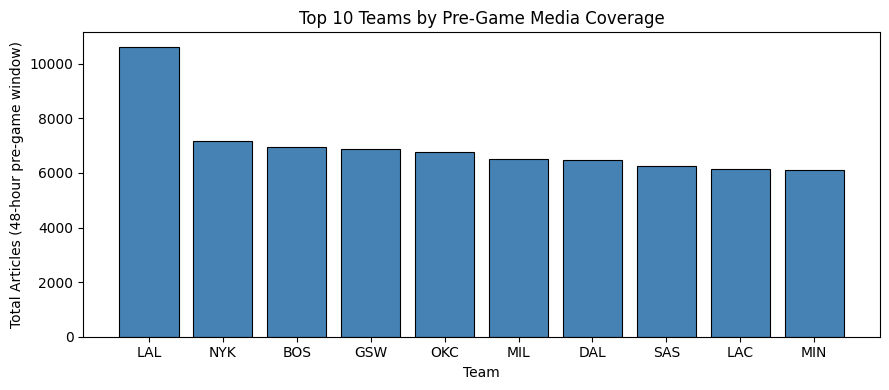

In [5]:
# Total article mentions per team across all games (team1 + team2 appearances)
team1_counts = df.groupby('team1')['team1_articles'].sum()
team2_counts = df.groupby('team2')['team2_articles'].sum()
total_coverage = (team1_counts.add(team2_counts, fill_value=0)
                  .sort_values(ascending=False)
                  .head(10))

plt.figure(figsize=(9, 4))
plt.bar(total_coverage.index, total_coverage.values, color='steelblue', edgecolor='black', linewidth=0.8)
plt.xlabel('Team')
plt.ylabel('Total Articles (48-hour pre-game window)')
plt.title('Top 10 Teams by Pre-Game Media Coverage')
plt.tight_layout()
plt.savefig('analysis/fig_coverage_by_team.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/2m/5s9qv8k95f191b61vh3y6zfr0000gp/T/ipykernel_90544/1113930245.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calibration = df.groupby('prob_bin').agg(


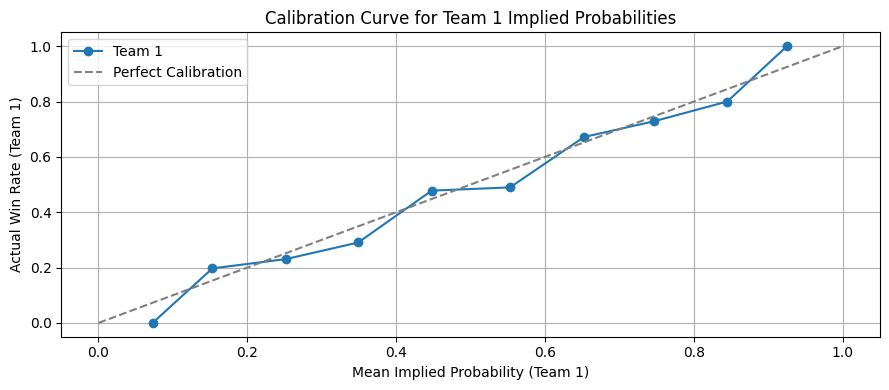

In [6]:
# plot calibration curve for team1 implied probabilities vs actual outcomes averaged by 10% bins
df['prob_bin'] = pd.cut(df['team1_implied_prob'], bins=np.arange(0, 1.1, 0.1))
calibration = df.groupby('prob_bin').agg(
    mean_implied_prob=('team1_implied_prob', 'mean'),
    actual_win_rate=('team1_won', 'mean'),
    count=('team1_won', 'count')
).reset_index()
plt.figure(figsize=(9, 4))
plt.plot(calibration['mean_implied_prob'], calibration['actual_win_rate'], marker='o', label='Team 1')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
plt.xlabel('Mean Implied Probability (Team 1)')
plt.ylabel('Actual Win Rate (Team 1)')
plt.title('Calibration Curve for Team 1 Implied Probabilities')
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig('analysis/fig_calibration_curve.png', dpi=150, bbox_inches='tight')
plt.show()

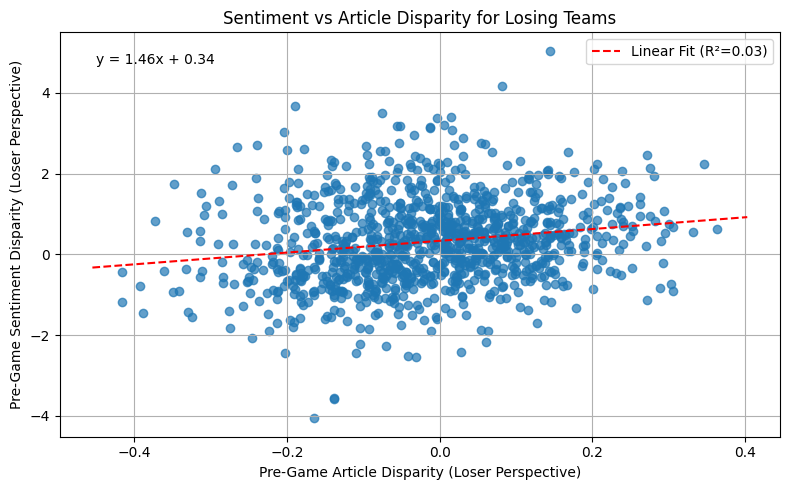

In [7]:
#Plot team1_avg_sentiment disparity vs article disparity for losers
df['sentiment_disparity_loser'] = np.where(
    df['winner'] == df['team1'],
    -df['team1_avg_tone']-df['team2_avg_tone'],   # team1 won -> loser is team2 -> flip sign
    df['team1_avg_tone']-df['team2_avg_tone']     # team2 won -> loser is team1 -> keep sign
)  
plt.figure(figsize=(8, 5))
plt.scatter(df['media_disparity_loser'], df['sentiment_disparity_loser'], alpha=0.7)
#add a linear regression line
slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(df['media_disparity_loser'], df['sentiment_disparity_loser'])
x_vals = np.array(plt.gca().get_xlim())
y_vals = intercept + slope * x_vals
plt.plot(x_vals, y_vals, color='red', linestyle='--', label=f'Linear Fit (R²={r_value**2:.2f})')
#add equation text
plt.text(0.05, 0.95, f'y = {slope:.2f}x + {intercept:.2f}', transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.legend()
plt.xlabel('Pre-Game Article Disparity (Loser Perspective)')
plt.ylabel('Pre-Game Sentiment Disparity (Loser Perspective)')
plt.title('Sentiment vs Article Disparity for Losing Teams')
plt.grid()
plt.tight_layout()
plt.savefig('analysis/fig_sentiment_vs_article_disparity.png', dpi=150, bbox_inches='tight')
plt.show()


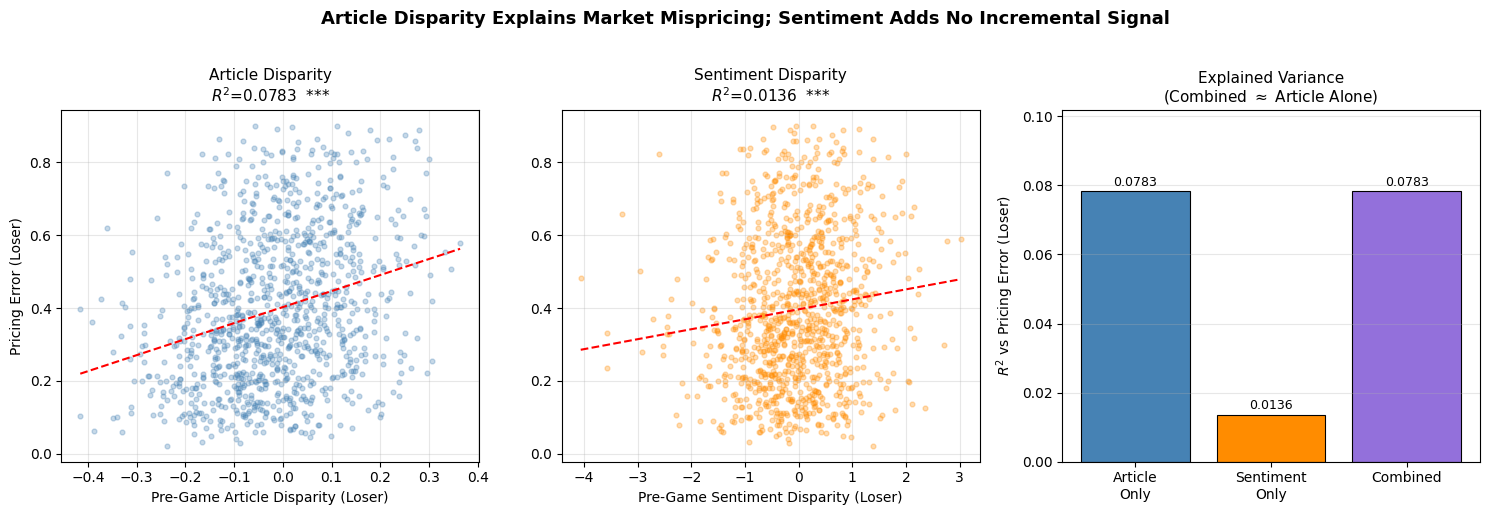

Article-only R²:  0.0783
Sentiment-only R²: 0.0136
Combined R²:       0.0783
Sentiment incremental gain: +0.0000


In [8]:
# Which is a better predictor of market mispricing: article disparity or sentiment disparity?
# Argument: sentiment adds no incremental signal beyond article count alone.

#calculate sentiment disparity from the loser's perspective (positive = loser had better pre-game press)
df['sentiment_disparity_loser'] = np.where(
    df['winner'] == df['team1'],
    df['team2_avg_tone'] - df['team1_avg_tone'],  # loser=team2
    df['team1_avg_tone'] - df['team2_avg_tone']   # loser=team1
)

outcome = 'pricing_error_loser'

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, color, label in [
    (axes[0], 'media_disparity_loser',    'steelblue',  'Article Disparity'),
    (axes[1], 'sentiment_disparity_loser', 'darkorange', 'Sentiment Disparity'),
]:
    x = df[col].values
    y = df[outcome].values
    slope, intercept, r, p, _ = scipy.stats.linregress(x, y)
    ax.scatter(x, y, alpha=0.30, color=color, s=12)
    xl = np.array([x.min(), x.max()])
    ax.plot(xl, intercept + slope * xl, 'r--', linewidth=1.5)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
    ax.set_title(f'{label}\n$R^2$={r**2:.4f}  {sig}', fontsize=11)
    ax.set_xlabel(f'Pre-Game {label} (Loser)')
    ax.set_ylabel('Pricing Error (Loser)' if ax is axes[0] else '')
    ax.grid(alpha=0.3)

# Panel 3: OLS R² for media-only, sentiment-only, and combined
r2_media    = smf.ols(f'{outcome} ~ media_disparity_loser',                              data=df).fit().rsquared
r2_sent     = smf.ols(f'{outcome} ~ sentiment_disparity_loser',                          data=df).fit().rsquared
r2_combined = smf.ols(f'{outcome} ~ media_disparity_loser + sentiment_disparity_loser',  data=df).fit().rsquared

bar_labels = ['Article\nOnly', 'Sentiment\nOnly', 'Combined']
bar_vals   = [r2_media, r2_sent, r2_combined]
bar_colors = ['steelblue', 'darkorange', 'mediumpurple']
bars = axes[2].bar(bar_labels, bar_vals, color=bar_colors, edgecolor='black', linewidth=0.8)
for bar, v in zip(bars, bar_vals):
    axes[2].text(bar.get_x() + bar.get_width() / 2, v + max(bar_vals) * 0.01,
                 f'{v:.4f}', ha='center', va='bottom', fontsize=9)
axes[2].set_ylabel('$R^2$ vs Pricing Error (Loser)')
axes[2].set_title('Explained Variance\n(Combined $\\approx$ Article Alone)', fontsize=11)
axes[2].set_ylim(0, max(bar_vals) * 1.3)
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle(
    'Article Disparity Explains Market Mispricing; Sentiment Adds No Incremental Signal',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('analysis/fig_disparity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Article-only R²:  {r2_media:.4f}')
print(f'Sentiment-only R²: {r2_sent:.4f}')
print(f'Combined R²:       {r2_combined:.4f}')
print(f'Sentiment incremental gain: {r2_combined - r2_media:+.4f}')


## Section 2: Hypothesis Testing

**Grouping strategy:** We split games by the *sign* of `media_disparity_loser` rather than its absolute magnitude.

- **Group A** (`media_disparity_loser > 0`): loser had *more* pre-game coverage → market may have overpriced them
- **Group B** (`media_disparity_loser ≤ 0`): loser had *less* coverage → market less likely to overprice

Using absolute disparity (high vs. low) would mix the two directions and cause the effects to cancel — masking any real signal. The signed grouping preserves the directional structure of the hypothesis.

In [9]:
pos_vals = df[df['media_disparity_loser'] > 0]['loser_implied_prob'].dropna().values
neg_vals = df[df['media_disparity_loser'] <= 0]['loser_implied_prob'].dropna().values

observed_diff = pos_vals.mean() - neg_vals.mean()

print(f'Group A — loser had MORE coverage: n={len(pos_vals):,}, mean={pos_vals.mean():.4f}')
print(f'Group B — loser had LESS coverage: n={len(neg_vals):,}, mean={neg_vals.mean():.4f}')
print(f'Observed mean difference (A − B):  {observed_diff:.4f}')

Group A — loser had MORE coverage: n=486, mean=0.4469
Group B — loser had LESS coverage: n=583, mean=0.3526
Observed mean difference (A − B):  0.0943


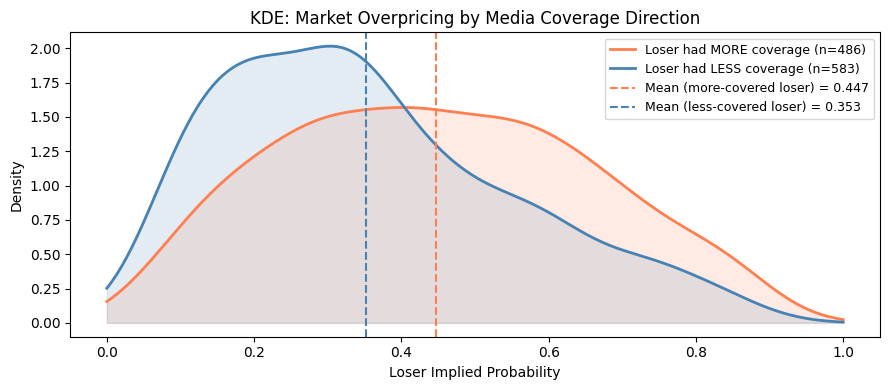

In [10]:
# Gaussian KDE: pricing-error distributions for high-coverage vs low-coverage losers
# Split on SIGNED disparity — positive = loser had more coverage, negative = loser had less
pos_group = df[df['media_disparity_loser'] > 0]['loser_implied_prob'].dropna()
neg_group = df[df['media_disparity_loser'] <= 0]['loser_implied_prob'].dropna()

kde_pos = scipy.stats.gaussian_kde(pos_group)
kde_neg = scipy.stats.gaussian_kde(neg_group)
x_vals = np.linspace(0, 1, 300)

plt.figure(figsize=(9, 4))
plt.plot(x_vals, kde_pos(x_vals), color='coral', linewidth=2, label=f'Loser had MORE coverage (n={len(pos_group):,})')
plt.plot(x_vals, kde_neg(x_vals), color='steelblue', linewidth=2, label=f'Loser had LESS coverage (n={len(neg_group):,})')
plt.fill_between(x_vals, kde_pos(x_vals), alpha=0.15, color='coral')
plt.fill_between(x_vals, kde_neg(x_vals), alpha=0.15, color='steelblue')
plt.axvline(pos_group.mean(), color='coral', linestyle='--', linewidth=1.5,
            label=f'Mean (more-covered loser) = {pos_group.mean():.3f}')
plt.axvline(neg_group.mean(), color='steelblue', linestyle='--', linewidth=1.5,
            label=f'Mean (less-covered loser) = {neg_group.mean():.3f}')
plt.xlabel('Loser Implied Probability')
plt.ylabel('Density')
plt.title('KDE: Market Overpricing by Media Coverage Direction')
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig('analysis/fig_sentiment_dist.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Permutation test (one-sided): H1 = Group A mean > Group B mean
nb_permutations = 10_000
combined = np.concatenate([pos_vals, neg_vals])
nb_pos = len(pos_vals)

perm_diffs = []
for i in range(nb_permutations):
    perm = np.random.permutation(combined)
    perm_diffs.append(perm[:nb_pos].mean() - perm[nb_pos:].mean())

p_val_permutation = np.mean(np.array(perm_diffs) >= observed_diff)

print(f'Permutation test (one-sided):')
print(f'  Observed difference:  {observed_diff:.4f}')
print(f'  p-value:              {p_val_permutation:.4f}')

Permutation test (one-sided):
  Observed difference:  0.0943
  p-value:              0.0000


In [12]:
# Welch t-test (does not assume equal variance)
result = scipy.stats.ttest_ind(pos_vals, neg_vals, equal_var=False)

print('Welch t-test:')
print(f'  statistic: {round(result.statistic, 4)}')
print(f'  pvalue:    {round(result.pvalue, 4)}')

Welch t-test:
  statistic: 7.5612
  pvalue:    0.0


/var/folders/2m/5s9qv8k95f191b61vh3y6zfr0000gp/T/ipykernel_90544/1036109375.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([pos_vals, neg_vals], labels=['Loser had\nMORE coverage', 'Loser had\nLESS coverage'],


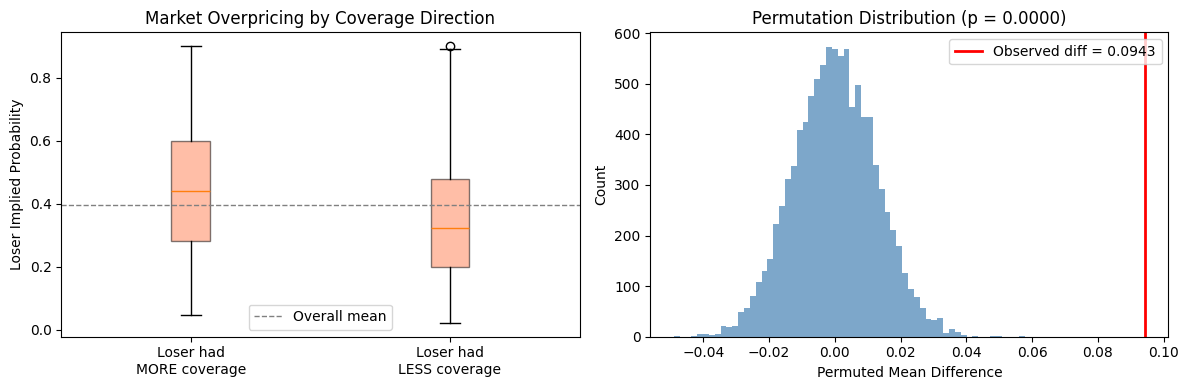

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Box plot comparison
axes[0].boxplot([pos_vals, neg_vals], labels=['Loser had\nMORE coverage', 'Loser had\nLESS coverage'],
                patch_artist=True,
                boxprops=dict(facecolor='coral', alpha=0.5))
axes[0].set_ylabel('Loser Implied Probability')
axes[0].set_title('Market Overpricing by Coverage Direction')
axes[0].axhline(df['loser_implied_prob'].mean(), color='gray', linestyle='--', linewidth=1,
                label='Overall mean')
axes[0].legend()

# Permutation distribution
axes[1].hist(perm_diffs, bins=60, edgecolor='none', alpha=0.7, color='steelblue')
axes[1].axvline(observed_diff, color='red', linewidth=2,
                label=f'Observed diff = {observed_diff:.4f}')
axes[1].set_xlabel('Permuted Mean Difference')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Permutation Distribution (p = {p_val_permutation:.4f})')
axes[1].legend()

plt.tight_layout()
plt.savefig('analysis/fig_hypothesis_media.png', dpi=150, bbox_inches='tight')
plt.show()

## Discussion of Results:
There is a statistically significant difference in loser implied probabilities between the two groups, with Group A (losers with more pre-game coverage) having a higher average implied probability than Group B. This supports the hypothesis that media coverage disparity is associated with market mispricing, however, this does not take into account that better teams may receive more coverage, so we cannot conclude causality from this analysis alone. Further analysis controlling for team quality would be needed to strengthen the argument. This is done in Section 3. 

## Section 3: Kalshi-Free Logistic Regression

**Goal:** Build a model that predicts game outcomes using only pregame statistics and media coverage — no Kalshi market prices. This produces a model-implied win probability that is independent of the market. Comparing it against Kalshi's implied probability then identifies potential mispricings.


In [14]:
df.columns

Index(['event_ticker', 'game_date', 'team1', 'team2', 'winner', 'loser',
       'winner_implied_prob', 'loser_implied_prob', 'team1_articles',
       'team2_articles', 'team1_avg_tone', 'team2_avg_tone',
       'team1_avg_positive', 'team2_avg_positive', 'team1_avg_negative',
       'team2_avg_negative', 'team1_avg_polarity', 'team2_avg_polarity',
       'mention_ratio_t1', 'tone_diff_t1_minus_t2',
       'polarity_diff_t1_minus_t2', 'media_disparity_t1',
       'pricing_error_winner', 'pricing_error_loser', 'game_date_pregame',
       'team1_pregame', 'team2_pregame', 'winner_pregame', 'team1_home',
       'season', 'winner_implied_prob_pregame', 't1_roll_win_pct',
       't1_roll_pts', 't1_roll_opp_pts', 't1_roll_pm', 't1_roll_fg_pct',
       't1_roll_fg3_pct', 't1_roll_ft_pct', 't1_roll_reb', 't1_roll_ast',
       't1_roll_tov', 't1_roll_stl', 't1_roll_blk', 't1_rest_days',
       't2_roll_win_pct', 't2_roll_pts', 't2_roll_opp_pts', 't2_roll_pm',
       't2_roll_fg_pct', 't2_roll_fg

In [15]:
#use diff columns for regression as well as media disparity
features = [
    # pregame performance differentials (team1 − team2)
    'diff_roll_win_pct',
    'diff_roll_pts',
    'diff_roll_opp_pts',
    'diff_roll_pm',
    'diff_roll_fg_pct',
    'diff_roll_fg3_pct',
    'diff_roll_ft_pct',
    'diff_roll_reb',
    'diff_roll_ast',
    'diff_roll_tov',
    'diff_roll_stl',
    'diff_roll_blk',
    'diff_rest_days',
    # context
    #'team1_home',#all zeros, so not useful for regression
    # media (tone excluded — no incremental signal)
    # 'media_disparity_t1', #wait to compare model with vs without media features, so exclude from feature set for now
]

target = 'team1_won'

X = df[features]
y = df[target]


In [16]:
#Correlation-based feature selection
corr_with_outcome = X.corrwith(df[target]).abs().sort_values(ascending=False)
print("=== Pearson |R| with team1_won ===")
print(corr_with_outcome.round(4).to_string())

selected_features = corr_with_outcome[corr_with_outcome > 0.05].index.tolist()
print(f"\nFeatures retained (|R| > 0.05): {selected_features}")


=== Pearson |R| with team1_won ===
diff_roll_pm         0.3725
diff_roll_opp_pts    0.3504
diff_roll_win_pct    0.3462
diff_roll_reb        0.1695
diff_roll_fg_pct     0.1596
diff_roll_tov        0.1588
diff_roll_pts        0.1570
diff_roll_fg3_pct    0.0949
diff_roll_blk        0.0913
diff_roll_ft_pct     0.0705
diff_roll_stl        0.0466
diff_roll_ast        0.0303
diff_rest_days       0.0300

Features retained (|R| > 0.05): ['diff_roll_pm', 'diff_roll_opp_pts', 'diff_roll_win_pct', 'diff_roll_reb', 'diff_roll_fg_pct', 'diff_roll_tov', 'diff_roll_pts', 'diff_roll_fg3_pct', 'diff_roll_blk', 'diff_roll_ft_pct']


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
base_model = LogisticRegression()
# x is difference in pregame features between team1 and team2, y is whether team1 won
X = X[selected_features]
X_scaled = scaler.fit_transform(X)

base_model.fit(X_scaled, y)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [18]:
#print feature importances by column name and absolute value of coefficients
coef_df = pd.DataFrame({
    'feature': selected_features,
    'coefficient': base_model.coef_[0],
    'abs_coefficient': np.abs(base_model.coef_[0])
}).sort_values(by='abs_coefficient', ascending=False)
print('Feature importances (by absolute coefficient value):')
print(coef_df[['feature', 'coefficient']])

Feature importances (by absolute coefficient value):
             feature  coefficient
1  diff_roll_opp_pts    -0.436317
0       diff_roll_pm     0.361694
2  diff_roll_win_pct     0.126018
5      diff_roll_tov    -0.099641
8      diff_roll_blk    -0.081238
4   diff_roll_fg_pct     0.050911
3      diff_roll_reb     0.047947
6      diff_roll_pts     0.030244
9   diff_roll_ft_pct    -0.023029
7  diff_roll_fg3_pct    -0.022750


In [19]:
#add media disparity to the model and see if it improves performance
X_media = df[selected_features + ['media_disparity_t1']]
X_media_scaled = scaler.fit_transform(X_media)
media_model = LogisticRegression()
media_model.fit(X_media_scaled, y)

#print feature importances for media model
coef_media_df = pd.DataFrame({
    'feature': selected_features + ['media_disparity_t1'],
    'coefficient': media_model.coef_[0],
    'abs_coefficient': np.abs(media_model.coef_[0])
}).sort_values(by='abs_coefficient', ascending=False)
print('Media model feature importances (by absolute coefficient value):')
print(coef_media_df[['feature', 'coefficient']])

Media model feature importances (by absolute coefficient value):
               feature  coefficient
1    diff_roll_opp_pts    -0.429400
0         diff_roll_pm     0.358323
2    diff_roll_win_pct     0.120152
5        diff_roll_tov    -0.095812
8        diff_roll_blk    -0.072495
10  media_disparity_t1     0.063428
3        diff_roll_reb     0.047821
4     diff_roll_fg_pct     0.036647
6        diff_roll_pts     0.033587
7    diff_roll_fg3_pct    -0.020603
9     diff_roll_ft_pct    -0.017887


# Disscussion of Results: 
Media disparity was the 5th highest feature importance in the media model. This suggests that media coverage does have predictive power for game outcomes. Now let's see which model best aligns with actual outcomes and whether kalshi's implied probabilities are systematically biased relative to the model's predictions.

### The Core Dissociation: Media Predicts Prices More Than Outcomes

 Media disparity is statistically significantly correlated with both game outcomes (r = 0.13, p < 0.001) and Kalshi's pricing errors (r = 0.28, p < 0.001), but the effect sizes differ by 4.4.

Instead, the pricing correlation is far larger than the outcome correlation, which means the market is responding to media attention in excess of what the underlying competitive information warrants.

- Media disparity explains 1.8% of variance in game outcomes (quality-driven baseline)
- Media disparity explains 7.8%
 of variance in Kalshi's pricing errors (4.4× the baseline)

This excess is consistent with market participants overweighting media attention when forming beliefs about which team will win.

In [20]:
# Quantify the dissociation using Pearson r (r² equals OLS R² for a single predictor)
r_outcome, p_outcome = scipy.stats.pearsonr(df['media_disparity_t1'],    df['team1_won'])
r_pricing, p_pricing = scipy.stats.pearsonr(df['media_disparity_loser'], df['pricing_error_loser'])

media_coef_media = coef_media_df.set_index('feature').loc['media_disparity_t1', 'abs_coefficient']
top_coef         = coef_media_df['abs_coefficient'].max()

def sig_stars(p):
    return '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))

print("=== Dissociation: Media Attention Signal ===")
print(f"  Pearson r (media → game outcome):        r={r_outcome:.4f},  r²={r_outcome**2:.4f},  p={p_outcome:.4f}  {sig_stars(p_outcome)}")
print(f"  Pearson r (media → Kalshi pricing error): r={r_pricing:.4f},  r²={r_pricing**2:.4f},  p={p_pricing:.4e}  {sig_stars(p_pricing)}")
print()
print(f"  Logistic coef for media (abs):  {media_coef_media:.4f}")
print(f"  Logistic coef for top feature:  {top_coef:.4f}")
print(f"  Ratio (media / top):            {media_coef_media / top_coef:.2%}")
print()
print(f"  Media is {r_pricing**2 / r_outcome**2:.1f}× more predictive of pricing errors than game outcomes (by r²)")

=== Dissociation: Media Attention Signal ===
  Pearson r (media → game outcome):        r=0.1333,  r²=0.0178,  p=0.0000  ***
  Pearson r (media → Kalshi pricing error): r=0.2798,  r²=0.0783,  p=1.1187e-20  ***

  Logistic coef for media (abs):  0.0634
  Logistic coef for top feature:  0.4294
  Ratio (media / top):            14.77%

  Media is 4.4× more predictive of pricing errors than game outcomes (by r²)


# Step 5: Mispricing Analysis
We calculate the mispricing signal as the difference between our model's predicted probability and Kalshi's implied probability for the losing team. 

In [21]:
# Print Kalshi implied probabilities vs actual outcomes. Simple bar average chart to see difference.

actual_wins_team1 = df['team1_won'].mean()
kalshi_implied_prob_team1 = df['team1_implied_prob'].mean()
print(f'Actual win rate for Team 1: {actual_wins_team1:.4f}')
print(f'Average Kalshi implied probability for Team 1: {kalshi_implied_prob_team1:.4f}')
print(f'Difference (Actual - Kalshi): {actual_wins_team1 - kalshi_implied_prob_team1:+.4f}')


Actual win rate for Team 1: 0.4425
Average Kalshi implied probability for Team 1: 0.4562
Difference (Actual - Kalshi): -0.0137


In [22]:
media_model_prob = media_model.predict_proba(X_media_scaled)[:, 1]
base_model_prob  = base_model.predict_proba(X_scaled)[:, 1]
kalshi_prob      = df['team1_implied_prob'].values

# Paired differences: positive = model thinks team1 is MORE likely to win than Kalshi does
base_diff  = base_model_prob  - kalshi_prob
media_diff = media_model_prob - kalshi_prob

print(f"Base  model mean prediction:    {base_model_prob.mean():.4f}")
print(f"Media model mean prediction:    {media_model_prob.mean():.4f}")
print(f"Kalshi mean implied prob:        {kalshi_prob.mean():.4f}")
print()
print(f"Base  model mean difference:    {base_diff.mean():+.4f}")
print(f"Media model mean difference:    {media_diff.mean():+.4f}")

Base  model mean prediction:    0.4425
Media model mean prediction:    0.4425
Kalshi mean implied prob:        0.4562

Base  model mean difference:    -0.0137
Media model mean difference:    -0.0136


## Section 4: Are Model Predictions Significantly Different from Kalshi?

**Test:** For each game we compute the paired difference `model_prob − kalshi_implied_prob`.  
- **H₀:** Mean difference = 0 (model and Kalshi agree on average)  
- **H₁:** Mean difference ≠ 0 (systematic deviation — evidence of market bias)

We use a **one-sample paired t-test** (`ttest_1samp` with `popmean=0`) plus a **bootstrap 95 % CI** on the mean difference, consistent with the permutation approach used in Section 2.

In [23]:
def bootstrap_mean_ci(arr, n_boot=10_000, ci=0.95):
    boot_means = [np.random.choice(arr, size=len(arr), replace=True).mean()
                  for _ in range(n_boot)]
    lo = np.percentile(boot_means, (1 - ci) / 2 * 100)
    hi = np.percentile(boot_means, (1 + ci) / 2 * 100)
    return np.array(boot_means), lo, hi

results = {}
for label, diff in [('Base model', base_diff), ('Media model', media_diff)]:
    t_stat, p_val = scipy.stats.ttest_1samp(diff, popmean=0)
    boot_means, ci_lo, ci_hi = bootstrap_mean_ci(diff)
    results[label] = dict(
        mean=diff.mean(), t=t_stat, p=p_val,
        ci_lo=ci_lo, ci_hi=ci_hi, boot_means=boot_means
    )
    sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'n.s.'))
    print(f"{label}:")
    print(f"  Mean difference (model − Kalshi): {diff.mean():+.4f}")
    print(f"  Paired t-test: t={t_stat:.4f},  p={p_val:.4e}  {sig}")
    print(f"  Bootstrap 95% CI: [{ci_lo:+.4f}, {ci_hi:+.4f}]")
    print()

Base model:
  Mean difference (model − Kalshi): -0.0137
  Paired t-test: t=-3.0104,  p=2.6706e-03  **
  Bootstrap 95% CI: [-0.0226, -0.0048]

Media model:
  Mean difference (model − Kalshi): -0.0136
  Paired t-test: t=-3.0416,  p=2.4111e-03  **
  Bootstrap 95% CI: [-0.0223, -0.0048]



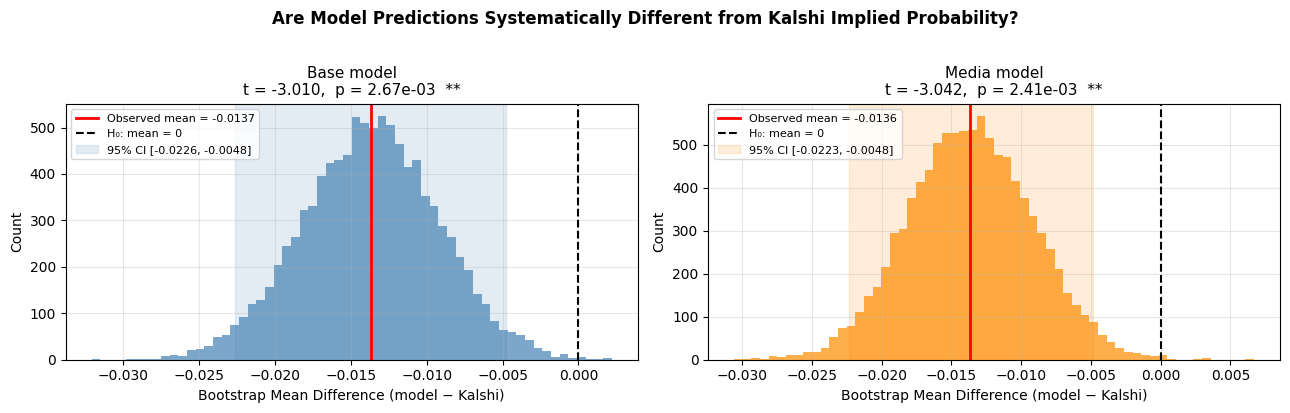

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (label, res), color in zip(
    axes,
    results.items(),
    ['steelblue', 'darkorange']
):
    ax.hist(res['boot_means'], bins=60, color=color, alpha=0.7, edgecolor='none')
    ax.axvline(res['mean'],  color='red',  linewidth=2,   label=f"Observed mean = {res['mean']:+.4f}")
    ax.axvline(0,            color='black', linewidth=1.5, linestyle='--', label='H₀: mean = 0')
    ax.axvspan(res['ci_lo'], res['ci_hi'], alpha=0.15, color=color,
               label=f"95% CI [{res['ci_lo']:+.4f}, {res['ci_hi']:+.4f}]")
    sig = '***' if res['p'] < 0.001 else ('**' if res['p'] < 0.01 else ('*' if res['p'] < 0.05 else 'n.s.'))
    ax.set_title(f"{label}\nt = {res['t']:.3f},  p = {res['p']:.2e}  {sig}", fontsize=11)
    ax.set_xlabel('Bootstrap Mean Difference (model − Kalshi)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Are Model Predictions Systematically Different from Kalshi Implied Probability?',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('analysis/fig_actual_vs_kalshi.png', dpi=150, bbox_inches='tight')
plt.show()